In [1]:
import torch

### set up CUDA as device if available
if torch.cuda.is_available():
    print("GPU is available")
    device = torch.device("cuda")
    cuda_id = torch.cuda.current_device()
    print(f"ID of current CUDA device:{torch.cuda.current_device()}")
    print(f"Name of current CUDA device:{torch.cuda.get_device_name(cuda_id)}")
    print(f"CUDA version: {torch.version.cuda}")
else:
    print("GPU is not available, using CPU")
    device = torch.device("cpu")
print(f"device: {device}")

GPU is available
cuda
CUDA version: 12.4
ID of current CUDA device:0
Name of current CUDA device:NVIDIA H200


In [2]:
import numpy as np
import random
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm, trange
from IPython import display
from sklearn.metrics import average_precision_score
from conf_and_plot import confusion_matrix_plots
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import re
import seaborn as sns

def seed_all(seed):
    if not seed:
        seed = 10

    print("[ Using Seed : ", seed, " ]")

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.cuda.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

seed_all(2025)

[ Using Seed :  2025  ]


In [3]:
scint_thresh = 0.1 # set the phase scintillation threshold

### following variable not being used anywhere
scint_outlier_thresh = 5. # set the value that determines phase scintillation outliers (these data samples will be removed)

processed_data_2015 = pd.read_csv("processed_data_2015.csv")
processed_data_2015 = processed_data_2015.drop(processed_data_2015.columns[0], axis=1)
predicted_label = 'sigmaPhi projected to vertical at prediction time [radians]'
y = processed_data_2015[predicted_label].values
print(y.shape)

X_fSelect = processed_data_2015.drop(predicted_label, axis=1)
X_fSelect = X_fSelect.values
print(X_fSelect.shape)

y_test_raw_2015 = pd.read_csv("2015_y_test_4365846.csv")
test_datetime_2015 = pd.read_csv("2015_test_datetime_4365846.csv")
test_datetime_2015 = test_datetime_2015.drop(test_datetime_2015.columns[0], axis=1)
test_datetime_2015['datetime'] = pd.to_datetime(test_datetime_2015['datetime'])
test_datetime_2015['predicted_datetime'] = pd.to_datetime(test_datetime_2015['predicted_datetime'])
test_station_2015 = pd.read_csv("2015_test_station_4365846.csv")


(4465846,)
(4465846, 15)


In [4]:
### tss model 19-11 cos
params = {'cnn_filters': 4, 
          'fc_size': 768, 
          'sequence_length': 45, 
          'dropout_p': 0.5, 
          'batch_size': 128, 
          'lr': 0.005, 
          'optimizer_type': 'sgd', 
          'weight_decay': 0.01, 
          'loss': 'bce', 
          'bce_pos_class_weight': 60, 
          'num_epochs': 150, 
          'scheduler_t': 115, 
          'scheduler_type': 'cos'}

### parameters
cnn_filters=4
fc_size=768
seq_length = 45
dropout_p= 0.5
batch_size= 128
learning_rate= 0.005
optimizer_type='sgd'
weight_decay = 0.01
loss = 'bce'
bce_pos_class_weight= 60
sgd_momentum = 0.9

num_epochs = 150
scheduler_type = 'cos'  # None, 'plat', or 'cos'
scheduler_t = 115  # for 'cos'
metric = 'tss' # metric for 'plat' scheduler : 'tss' or 'hss'

training_data_size = 50000
test_data_size = 4365846

# final train tss = 0.7012 : final val tss = 0.6722
# final train hss = 0.1737 : final val hss = 0.3020
# test_TSS_2016: 0.5888
# test_HSS_2016: 0.1610
# AUC-ROC: 0.87
# Precision-Recall AUC: 0.19


In [5]:
# Convert y to binary values (1=scintillation; 0=no-scintillation)
y[y>scint_thresh] = 1
y[y<=scint_thresh] = 0

X_train, X_test, \
    y_train, y_test, \
        idx_train, idx_test = train_test_split(X_fSelect, y, range(len(y)), train_size=training_data_size, shuffle=False)
X_val, X_test, \
    y_val, y_test, \
        idx_val, idx_test = train_test_split(X_test, y_test, range(len(y_test)), test_size=test_data_size, shuffle=False)

# Create input data scaler based only on training set
scaler_X = RobustScaler()
scaler_X = scaler_X.fit(X_train)

X_train_scaled = scaler_X.transform(X_train)
X_val_scaled = scaler_X.transform(X_val)
X_test_scaled = scaler_X.transform(X_test)

def reshape_data_to_seq_length(data, seq_len):
    num_samples = data.shape[0]
    input_features = data.shape[1]
    num_batches = num_samples // seq_len
    data = data[:num_batches * seq_len]
    reshaped_data = data.reshape(num_batches, seq_len, input_features)
    return reshaped_data

def reshape_labels_to_seq_length(labels, seq_len):
    labels = torch.from_numpy(labels) if isinstance(labels, np.ndarray) else labels
    num_samples = labels.shape[0]
    num_batches = num_samples // seq_len
    labels = labels[:num_batches * seq_len]
    labels = labels.view(num_batches, seq_len, -1)
    return labels

X_train_scaled = reshape_data_to_seq_length(X_train_scaled, seq_length)
X_val_scaled = reshape_data_to_seq_length(X_val_scaled, seq_length)
X_test_scaled = reshape_data_to_seq_length(X_test_scaled, seq_length)

train_labels = reshape_labels_to_seq_length(y_train, seq_length)
val_labels = reshape_labels_to_seq_length(y_val, seq_length)
test_labels = reshape_labels_to_seq_length(y_test, seq_length)

# train_data = torch.tensor(X_train_scaled, dtype=torch.float32)
train_data = torch.tensor(X_train_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
train_data = train_data.to(device)
train_labels = train_labels.to(device)
dataset = TensorDataset(train_data, train_labels)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

# val_data = torch.tensor(X_val_scaled, dtype=torch.float32)
val_data = torch.tensor(X_val_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
val_data = val_data.to(device)
val_labels = val_labels.to(device)
val_dataset = TensorDataset(val_data, val_labels)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

# test_data = torch.tensor(X_test_scaled, dtype=torch.float32)
test_data = torch.tensor(X_test_scaled, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
test_data = test_data.to(device)
test_labels = test_labels.to(device)
test_dataset = TensorDataset(test_data, test_labels)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, worker_init_fn=seed_worker)

In [6]:
def true_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    tss = (TP / (TP + FN)) - (FP / (FP + TN))
    return tss

def heidke_skill_score(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    
    numerator = 2 * (TP * TN - FP * FN)
    denominator = (TP + FP) * (FP + TN) + (TP + FN) * (TN + FP)
    
    # Avoid division by zero
    if denominator == 0:
        return 0.0
    
    hss = numerator / denominator
    return hss

In [7]:
class simple_timeSeries_CNN(nn.Module):
    def __init__(self, cnn_filters, fc_size, dropout_p, loss, seq_length):
        super(simple_timeSeries_CNN, self).__init__()
        
        self.loss = loss
        self.seq_length = seq_length

        self.conv1 = nn.Conv1d(in_channels=15, out_channels=cnn_filters, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(num_features=cnn_filters)
        self.dropout = nn.Dropout(dropout_p)
        self.conv2 = nn.Conv1d(in_channels=cnn_filters, out_channels=cnn_filters*2, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(num_features=cnn_filters*2)
        self.pool = nn.MaxPool1d(2)

        # num_features = 25, MaxPool1d_size=2
        # 12 = round(25 / 2)
        # 6 = round(12 / 2)
        # self.fc1 = nn.Linear(cnn_filters * 2 * 6, fc_size)
        self.fc1 = nn.Linear(cnn_filters * 2 * (seq_length // 4), fc_size)
        # self.fc2 = nn.Linear(fc_size, 1)
        self.fc2 = nn.Linear(fc_size, seq_length)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.dropout(x)
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = x.view(x.size(0), -1) # Flatten the output for the fully connected layers
        x = torch.relu(self.fc1(x))
        x = self.fc2(x).view(x.size(0), self.seq_length, 1)

        if self.loss == 'focal':
            # x = torch.sigmoid(self.fc2(x))
            x = torch.sigmoid(x)
        elif self.loss == 'bce':
            # x = self.fc2(x)
            pass
        
        return x

In [8]:
def plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, epochs):
    
    lw = 0.8
    ms = 2
    ls = (0, (5, 10)) # loosely dashed
    ls = (0, (1, 5)) # dotted
    ls = (0, (1, 2)) # densely dotted
    
    # Create the figure and the first set of axes
    fig, ax1 = plt.subplots()
    
    ax1.plot(range(epochs), training_loss, color='b', linewidth=lw, label='training loss')
    ax1.plot(range(epochs), validation_loss, color='b', linewidth=lw, linestyle=ls, label='validation loss')
    ax1.set_xlabel('epochs')
    ax1.set_ylabel('loss', color='b')
    ax1.tick_params('y', colors='b')

    # Create a second set of axes sharing the same x-axis
    ax2 = ax1.twinx()

    ax2.plot(range(epochs), training_tss, color='r', linewidth=lw, label='training TSS')
    ax2.plot(range(epochs), validation_tss, color='r', linewidth=lw, linestyle=ls, label='validation TSS')

    ax2.plot(range(epochs), training_hss, color='orange', linewidth=lw, label='training HSS')
    ax2.plot(range(epochs), validation_hss, color='orange', linewidth=lw, linestyle=ls, label='validation TSS')
    ax2.set_ylabel('TSS/HSS', color='r')
    ax2.tick_params('y', colors='r')

    plt.title(f'Training and Validation Curves')
    fig.legend(loc='upper left')

    plt.show()


In [9]:
model = simple_timeSeries_CNN(cnn_filters=cnn_filters, fc_size=fc_size, dropout_p=dropout_p, loss=loss, seq_length=seq_length)
model.to(device)

criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([bce_pos_class_weight]).to(device))

if optimizer_type == 'adam':
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
elif optimizer_type == 'sgd':
    optimizer = optim.SGD(model.parameters(), lr=learning_rate, momentum=sgd_momentum, weight_decay=weight_decay)

# scheduler
if scheduler_type == None:
    pass
elif scheduler_type == 'cos':
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=scheduler_t)
elif scheduler_type == 'plat':
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 
               mode='max',      # 'min' for loss, 'max' for accuracy
               factor=0.1,      # How much to reduce the learning rate by
               patience=30,     # Number of epochs to wait before reducing
               threshold=0.05,  # Minimum change to qualify as an improvement
               cooldown=25,      # Number of epochs to wait before reducing again
               min_lr=1e-6)     # Lower bound on learning rate
            

100%|██████████| 150/150 [00:04<00:00, 36.37it/s]


final train tss = 0.7012 : final val tss = 0.6722
final train hss = 0.1737 : final val hss = 0.3020


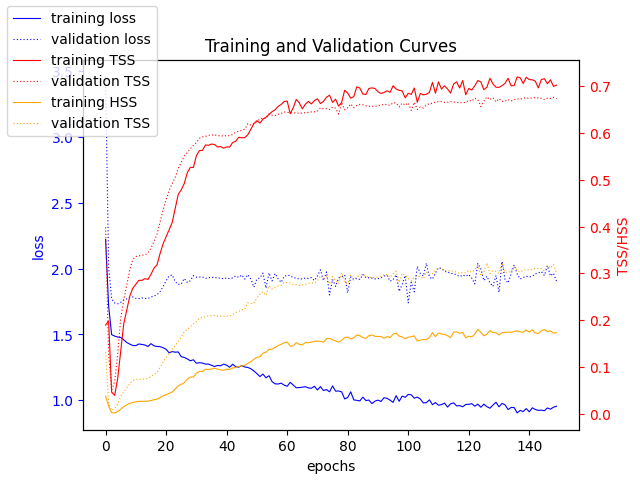

In [10]:
epochs = []
training_loss = []
validation_loss = []
training_tss = []
validation_tss = []
training_hss = []
validation_hss = []

previous_lr = optimizer.param_groups[0]['lr']

# for epoch in range(num_epochs):
for epoch in trange(num_epochs):
    
#     ### early stop for tss model
#     if epoch >= 41:
#         continue

    ### training loop
    model.train()
    running_loss = 0.0
    predicted_training_labels = np.array([])
    y_train = np.array([])
    
#     for data, target in tqdm(dataloader):
    for data, target in dataloader:
        
        data = data.to(device)
        target = target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        output.to(device)
        loss = criterion(output, target.float())
        loss.backward()
        optimizer.step()
        
        if scheduler_type == 'cos':
            scheduler.step()
            
        running_loss += loss.item()
        with torch.no_grad(): predicted_training_labels = np.append(predicted_training_labels, output.cpu())
        with torch.no_grad(): y_train = np.append(y_train, target.cpu())

    predicted_training_labels = np.where(predicted_training_labels > 0.1, 1, 0)

    train_loss = running_loss / len(dataloader)
    train_tss = true_skill_score(y_train.astype(int), predicted_training_labels.astype(int))
    train_hss = heidke_skill_score(y_train.astype(int), predicted_training_labels.astype(int))

    ### validation loop
    model.eval()
    with torch.no_grad():
        running_loss = 0.0
        predicted_val_labels = np.array([])
        y_val = np.array([])

#         for batch_data, labels in tqdm(val_dataloader):
        for batch_data, labels in val_dataloader:
        
            batch_data = batch_data.to(device)
            labels = labels.to(device)
            
            outputs = model(batch_data)
            outputs.to(device)
            loss = criterion(outputs, labels.float())
            running_loss += loss.item()
            predicted_val_labels = np.append(predicted_val_labels, outputs.cpu())
            y_val = np.append(y_val, labels.cpu())
            
    predicted_val_labels = np.where(predicted_val_labels > 0.1, 1, 0)

    val_loss = running_loss / len(val_dataloader)
    val_tss = true_skill_score(y_val.astype(int), predicted_val_labels.astype(int))
    val_hss = heidke_skill_score(y_val.astype(int), predicted_val_labels.astype(int))

#     print(f"Epoch [{epoch+1}/{num_epochs}]", end="\n\n")

#     print(f"Training Loss: {train_loss:.4f}, Training TSS: {train_TSS:.4f}")
#     print(f"Validation Loss: {val_loss:.4f}, Validation TSS: {val_TSS:.4f}", end="\n\n")

    epochs.append(epoch)
    training_loss.append(train_loss)
    validation_loss.append(val_loss)
    training_tss.append(train_tss)
    validation_tss.append(val_tss)
    training_hss.append(train_hss)
    validation_hss.append(val_hss)
    
    if scheduler_type == 'plat':
        if metric == 'tss':
            scheduler.step(val_tss) # when tuning for tss
        elif metric == 'hss':
            scheduler.step(val_hss) # when tuning for hss
            
        current_lr = scheduler.get_last_lr()[0]
        if current_lr < previous_lr:
            print(f"Learning rate reduced to: {current_lr}")
        previous_lr = current_lr
    

print(f"final train tss = {training_tss[-1]:.4f} : final val tss = {validation_tss[-1]:.4f}")
print(f"final train hss = {training_hss[-1]:.4f} : final val hss = {validation_hss[-1]:.4f}")
# plot_training_validation_curves(training_tss, validation_tss, training_loss, validation_loss, num_epochs)
# plot_training_validation_curves(training_hss, validation_hss, training_loss, validation_loss, num_epochs-4)
# plot_training_validation_curves(training_hss, validation_hss, training_loss, validation_loss, num_epochs)
plot_training_validation_curves(training_hss, validation_hss, training_tss, validation_tss, training_loss, validation_loss, num_epochs)


In [11]:
test_data.shape

torch.Size([97018, 15, 45])

In [12]:
# ### good simple visual strategy - gradient of output wrt inputs
# x = 72

# model.eval()

# input_sample = test_data[x].unsqueeze(0)
# input_sample = input_sample.clone().detach()  
# input_sample.requires_grad_()
# output = model(input_sample)
# output_value = output[0, 0]
# output_value.backward()
# # print("Gradient with respect to the input:\n", input_sample.grad)

# num_features = input_sample.shape[1]
# feature_names = processed_data_2015.columns.tolist()
# feature_units = [re.search(r'\[(.*?)\]', name).group(1) for name in feature_names]

# fig, axes = plt.subplots(num_features + 3, 1, figsize=(10, 3 * (num_features + 1)), sharex=True)

# norm = plt.Normalize(vmin=input_sample.grad.min(), vmax=input_sample.grad.max())  
# cmap = plt.get_cmap("jet")  # Get the 'jet' colormap

# for feature_idx in range(num_features):
#     feature_data = input_sample[0, feature_idx, :].cpu().detach().numpy()  
#     grad_data = input_sample.grad[0, feature_idx, :].cpu().detach().numpy()  
    
#     ax = axes[feature_idx]
    
#     for i in range(len(feature_data) - 1):  # -1 to avoid out-of-bounds when connecting points
#         ax.plot([i, i + 1], [feature_data[i], feature_data[i + 1]], color=cmap(norm(grad_data[i])), lw=2)
    
#     ax.set_ylabel(f"{feature_names[feature_idx].split(' [')[0]}\n[{feature_units[feature_idx]}]", fontsize=12)
#     ax.set_ylim(np.min(feature_data) - 0.1, np.max(feature_data) + 0.1)  # Set y-axis limits for consistency
#     ax.grid(True)
    
# y_test_raw_2015 = pd.read_csv("2015_y_test_4365846.csv")

# raw_truth_ax = axes[-3]
# start = x * 110
# end = start + 110
# raw_truth_at_prediction_time = y_test_raw_2015[predicted_label][start:end]
# raw_truth_ax.plot(np.arange(input_sample.shape[2]), np.full_like(np.arange(input_sample.shape[2]), y_test_raw_2015[predicted_label][start:end]), color='black', lw=1)
# raw_truth_ax.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
# raw_truth_ax.set_ylabel("sigmaPhi \n projected to vertical \n at prediction time \n[radians]", fontsize=12)

# label_ax = axes[-2]
# test_label = test_labels[x].cpu().detach().numpy()
# label_ax.step(np.arange(input_sample.shape[2]), np.full_like(np.arange(input_sample.shape[2]), np.squeeze(test_label)), color='black', lw=2)
# label_ax.set_ylabel("Test Labels", fontsize=12)
# label_ax.set_ylim(-0.1, 1.1)  

# predicted_label_ax = axes[-1]  
# predicted_labels = np.where(output.cpu().detach() > 0.1, 1, 0)
# predicted_label_ax.step(np.arange(input_sample.shape[2]), np.full_like(np.arange(input_sample.shape[2]), np.squeeze(predicted_labels)), color='black', lw=2)
# predicted_label_ax.set_ylabel("Predicted Labels", fontsize=12)
# predicted_label_ax.set_ylim(-0.1, 1.1)  
# predicted_label_ax.set_xlabel("Time step (Sequence length)", fontsize=12)

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # Required to create the colorbar
# cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.05, pad=0.05)  # Increase fraction to make colorbar larger
# cbar.set_label('Gradient (Feature)', rotation=90, fontsize=14)  
# cbar.ax.set_position([0.92, 0.72, 0.03, 0.15]) 

# plt.suptitle("Gradient of Output W.R.T. Original 15 Feature Inputs Versus Time", fontsize=16, fontweight='bold', y=0.89)

# # plt.savefig('gradient_plot.png', dpi=300, bbox_inches='tight')
# plt.show()


In [13]:
# batch_indices = range(72, 74)

# all_input_samples = []
# all_gradients = []
# all_outputs = []
# all_raw_signals = []

# for x in batch_indices:
#     input_sample = test_data[x].unsqueeze(0)
#     input_sample = input_sample.clone().detach()
#     input_sample.requires_grad_()

#     output = model(input_sample)
#     output_value = output[0, 0]
#     output_value.backward()

#     all_input_samples.append(input_sample)
#     all_gradients.append(input_sample.grad)
#     all_outputs.append(output)
#     all_raw_signals.append(y_test_raw_2015[x].unsqueeze(0))

# all_input_samples = torch.cat(all_input_samples, dim=2)
# all_gradients = torch.cat(all_gradients, dim=2)
# all_outputs = torch.cat(all_outputs, dim=1)
# all_raw_signals = torch.cat(all_raw_signals, dim=2)


# feature_names = processed_data_2015.columns.tolist()
# feature_units = [re.search(r'\[(.*?)\]', name).group(1) for name in feature_names]

# fig, axes = plt.subplots(num_features + 3, 1, figsize=(10, 3 * (num_features + 1)), sharex=True)

# norm = plt.Normalize(vmin=all_gradients.min(), vmax=all_gradients.max())
# cmap = plt.get_cmap("jet")

# def delineate_sequences(axis):
#     for i in range(0, len(batch_indices)):
#         sequence_delineation = (i + 1)*seq_length
#         axis.axvline(x=sequence_delineation, color='#cc9900', linestyle=':', lw=1)

# for feature_idx in range(num_features):
#     feature_data = all_input_samples[0, feature_idx, :].cpu().detach().numpy()
#     grad_data = all_gradients[0, feature_idx, :].cpu().detach().numpy()

#     ax = axes[feature_idx]
#     for i in range(len(feature_data) - 1):  # -1 to avoid out-of-bounds
#         ax.plot([i, i + 1], [feature_data[i], feature_data[i + 1]], color=cmap(norm(grad_data[i])), lw=2)

#     ax.set_ylabel(f"{feature_names[feature_idx].split(' [')[0]}\n[{feature_units[feature_idx]}]", fontsize=12)
#     ax.set_ylim(np.min(feature_data) - 0.1, np.max(feature_data) + 0.1)
#     ax.grid(True)
#     delineate_sequences(ax)

# raw_truth_ax = axes[-3]
# raw_truth_ax.plot(np.arange(all_input_samples.shape[2]), np.squeeze(all_raw_signals), color='black', lw=1)
# raw_truth_ax.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
# raw_truth_ax.set_ylabel("sigmaPhi \n projected to vertical \n at prediction time \n[radians]", fontsize=12)
# raw_truth_ax.set_yscale('log')
# delineate_sequences(raw_truth_ax)

# label_ax = axes[-2]
# test_labels_range = test_labels[batch_indices].cpu().detach().numpy().flatten()  # Flatten for continuous sequence
# label_ax.step(np.arange(all_input_samples.shape[2]), np.full_like(np.arange(all_input_samples.shape[2]), test_labels_range), color='black', lw=2)
# label_ax.set_ylabel("Test Labels", fontsize=12)
# label_ax.set_ylim(-0.1, 1.1)
# delineate_sequences(label_ax)

# predicted_label_ax = axes[-1]
# predicted_labels = np.where(all_outputs.cpu().detach() > 0.1, 1, 0)
# predicted_label_ax.step(np.arange(all_input_samples.shape[2]), np.squeeze(predicted_labels), color='black', lw=2)
# predicted_label_ax.set_ylabel("Predicted Labels", fontsize=12)
# predicted_label_ax.set_ylim(-0.1, 1.1)
# predicted_label_ax.set_xlabel("Time step (Sequence length)", fontsize=12)
# delineate_sequences(predicted_label_ax)

# sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
# sm.set_array([])  # Required to create the colorbar
# cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.05, pad=0.05)
# cbar.set_label('Gradient (Feature)', rotation=90, fontsize=14)
# cbar.ax.set_position([0.92, 0.72, 0.03, 0.15])

# plt.suptitle("Gradient of Output W.R.T. Original 15 Feature Inputs Versus Time (for Multiple Batches)", fontsize=16, fontweight='bold', y=0.89)

# plt.show()


In [14]:
test_station_2015

,Unnamed: 0,CHAIN station
0,0,arv
1,1,arv
2,2,arv
3,3,arv
4,4,arv
...,...,...
4465841,4465841,rep
4465842,4465842,rep
4465843,4465843,rep
4465844,4465844,rep


In [15]:
# On 17 March 2015, the Sym-H index reached −234 nT at 22:47 UT (Figure 1d) 
#     which made this storm the strongest of solar cycle 24.
    
batch_indices = range(15013, 15015)
batch_indices = range(14888, 14901)
batch_indices = range(14889, 14901)
batch_indices = range(14887, 14900)

start_idx = batch_indices.start * seq_length
end_idx = batch_indices.stop * seq_length - 1
print(start_idx)
print(end_idx)

first_datetime = test_datetime_2015['datetime'].iloc[start_idx]
first_pred_datetime = test_datetime_2015['predicted_datetime'].iloc[start_idx]

first_station = test_station_2015['CHAIN station'].iloc[start_idx]
first_pred_station = test_station_2015['CHAIN station'].iloc[start_idx + 60]
last_station = test_station_2015['CHAIN station'].iloc[end_idx]
last_pred_station = test_station_2015['CHAIN station'].iloc[end_idx + 60]

last_datetime = test_datetime_2015['datetime'].iloc[end_idx]
last_pred_datetime = test_datetime_2015['predicted_datetime'].iloc[end_idx]

# Print the first and last datetime values
print(f"Input Time Range: {first_datetime} - {last_datetime}")
print(f"Predicted Time Range: {first_pred_datetime} - {last_pred_datetime}")
print(f"Input Station: {first_station} - {last_station}")
print(f"Predicted Station: {first_pred_station} - {last_pred_station}")


669915
670499
Input Time Range: 2015-03-17 06:12:00 - 2015-03-17 22:41:00
Predicted Time Range: 2015-03-17 07:12:00 - 2015-03-17 23:41:00
Input Station: fsi - fsi
Predicted Station: fsi - fsi


In [16]:
## DONT DELETE
q = reshape_labels_to_seq_length(y_test_raw_2015[predicted_label].to_numpy(), seq_length)
q = torch.tensor(q, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]
q.to(device)

/tmp/ipykernel_2797903/1849628327.py:3: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  q = torch.tensor(q, dtype=torch.float32).transpose(1, 2)  # Shape: [batch_size, 15, 1]


tensor([[[0.0341, 0.0319, 0.0299,  ..., 0.0361, 0.0311, 0.0364]],

        [[0.0369, 0.0313, 0.0313,  ..., 0.0348, 0.0380, 0.0380]],

        [[0.0383, 0.0360, 0.0384,  ..., 0.1202, 0.0982, 0.0739]],

        ...,

        [[0.2417, 0.3601, 0.3591,  ..., 0.0449, 0.0446, 0.0523]],

        [[0.0413, 0.0405, 0.0454,  ..., 0.0324, 0.0394, 0.0451]],

        [[0.0590, 0.0335, 0.0526,  ..., 0.0405, 0.0431, 0.0461]]],
       device='cuda:0')

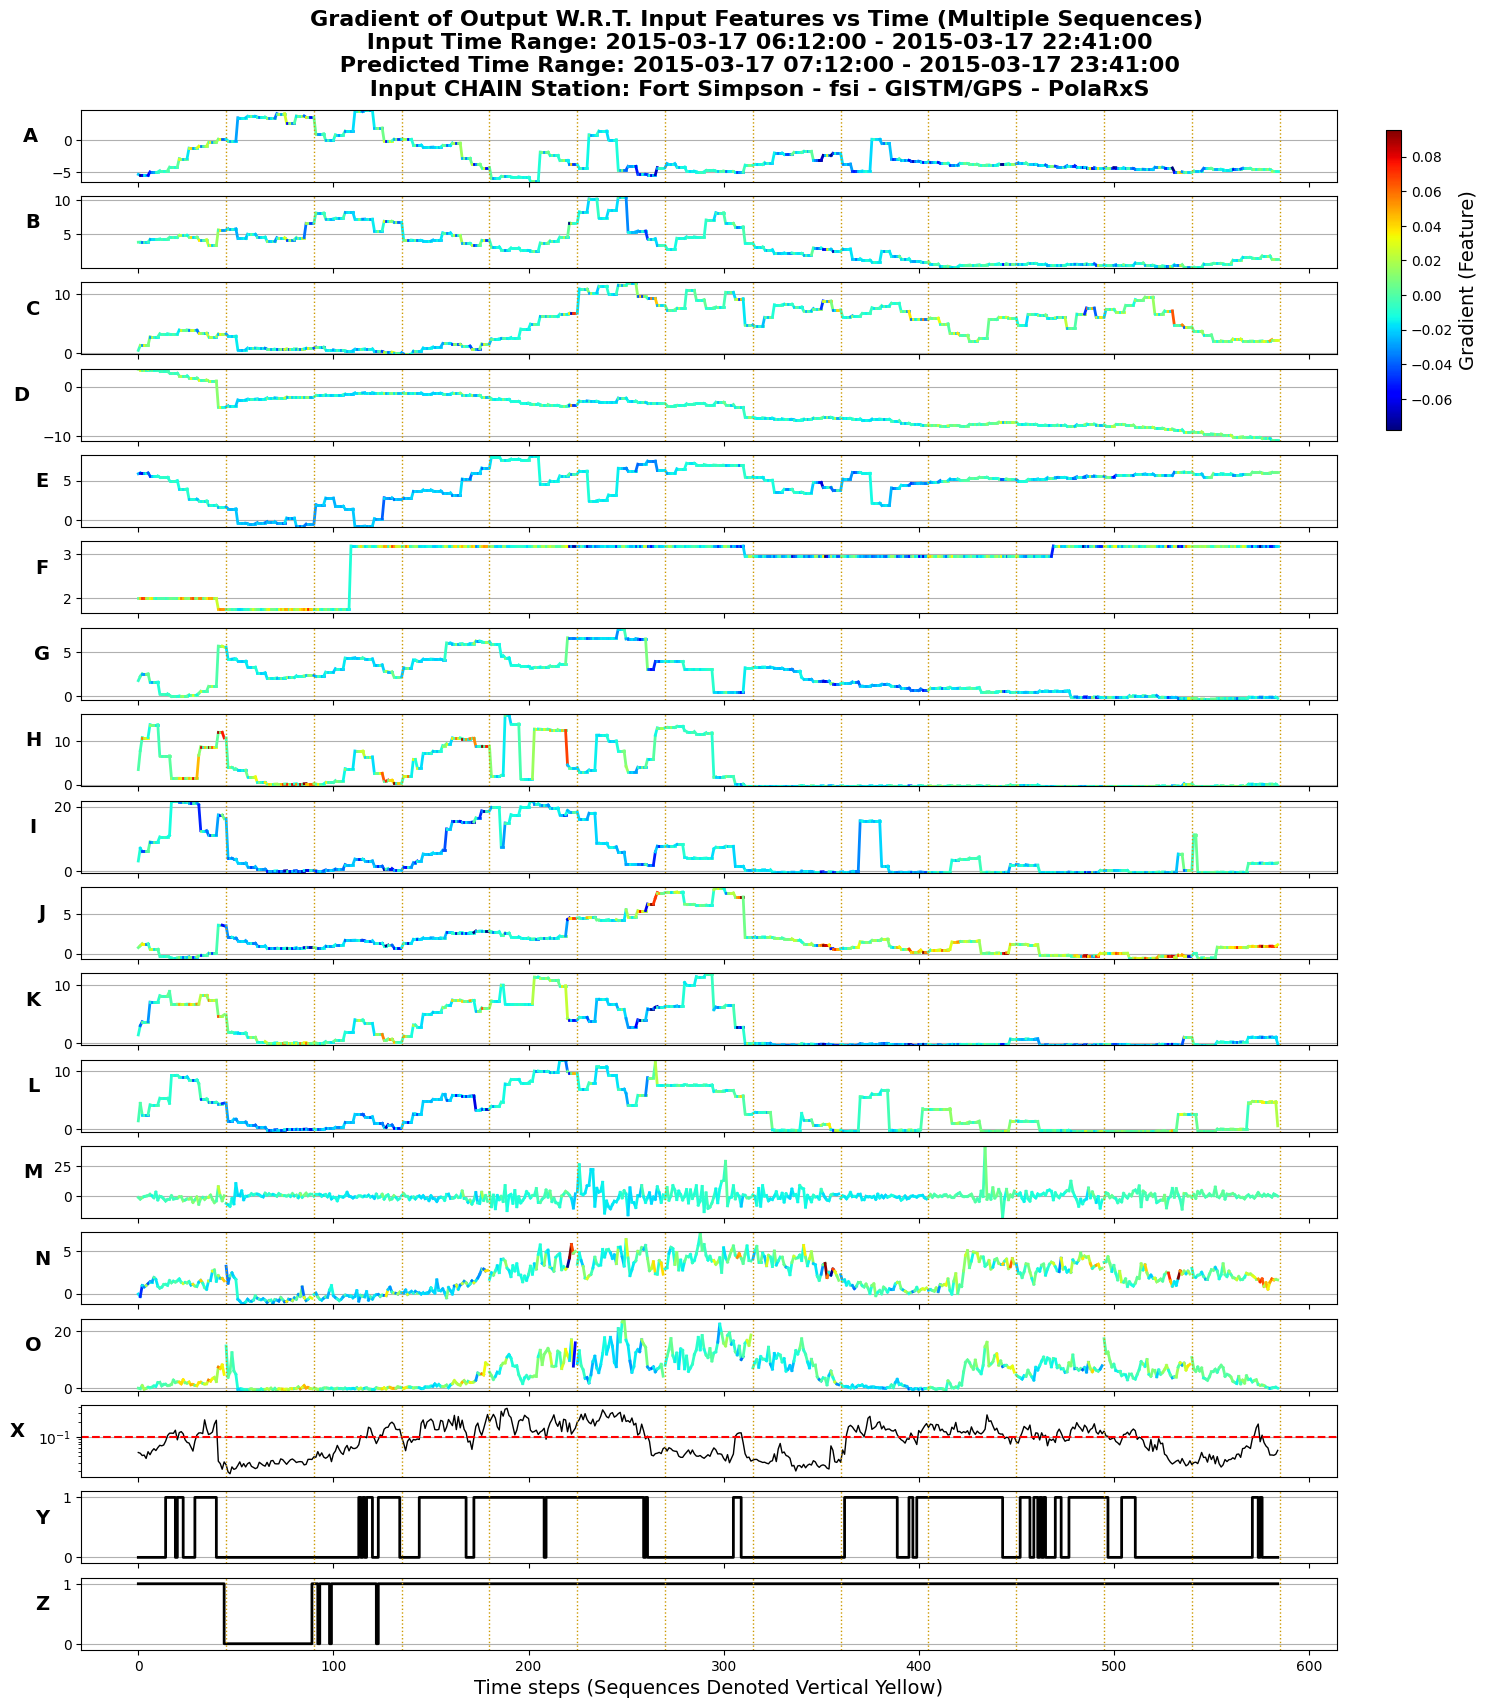

In [40]:
batch_indices = range(72, 75)
batch_indices = range(15013, 15015)
batch_indices = range(15012, 15018)
batch_indices = range(14851, 14856)
batch_indices = range(14895, 14901)
batch_indices = range(14888, 14901)  ### too big?????
batch_indices = range(14889, 14901)  ### too big?????
batch_indices = range(14887, 14900)  ### works sometimes I guess
# batch_indices = range(14887, 14890)

all_input_samples = []
all_gradients = []
all_outputs = []
all_raw_signals = []
batch_gradients = []

for x in batch_indices:
    input_sample = test_data[x].unsqueeze(0)
    input_sample = input_sample.clone().detach()
    input_sample.requires_grad_()

    output = model(input_sample)
    output_value = output[0, 0]
    output_value.backward()

    all_input_samples.append(input_sample)
    all_gradients.append(input_sample.grad)
    all_outputs.append(output)
#     all_raw_signals.append(y_test_raw_2015[x].unsqueeze(0))
    all_raw_signals.append(q[x].unsqueeze(0))
    
    batch_gradients.append(input_sample.grad)

all_input_samples = torch.cat(all_input_samples, dim=2)
all_gradients = torch.cat(all_gradients, dim=2)

all_outputs = torch.cat(all_outputs, dim=1)
all_raw_signals = torch.cat(all_raw_signals, dim=2)


feature_names = processed_data_2015.columns.tolist()
feature_units = [re.search(r'\[(.*?)\]', name).group(1) for name in feature_names]
num_features = test_data.shape[1]

# fig, ax = plt.subplots(figsize=(9, 5))
# fig, axes = plt.subplots(num_features + 3, 1, figsize=(10, 3 * (num_features + 1)), sharex=True)
# fig, axes = plt.subplots(num_features + 3, 1, figsize=(8, 1.3 * (num_features + 1)), sharex=True)
fig, axes = plt.subplots(num_features + 3, 1, figsize=(18, 1.25 * (num_features + 1)), sharex=True)

norm = plt.Normalize(vmin=all_gradients.min(), vmax=all_gradients.max())
cmap = plt.get_cmap("jet")

def delineate_sequences(axis):
    for i in range(0, len(batch_indices)):
        sequence_delineation = (i + 1)*seq_length
        axis.axvline(x=sequence_delineation, color='#cc9900', linestyle=':', lw=1)


for batch_idx in range(0, len(batch_indices)):
    sequence_delineation = (batch_idx + 1)*seq_length
    
    batch_norm = plt.Normalize(vmin=batch_gradients[batch_idx].min(), vmax=batch_gradients[batch_idx].max())
    
    for feature_idx in range(num_features):
        if batch_idx == 0:
            feature_data = all_input_samples[0, feature_idx, 0:sequence_delineation].cpu().detach().numpy()
            grad_data = all_gradients[0, feature_idx, 0:sequence_delineation].cpu().detach().numpy()
        else:
            feature_data = all_input_samples[0, feature_idx, prev_sequence_delineation:sequence_delineation].cpu().detach().numpy()
            grad_data = all_gradients[0, feature_idx, prev_sequence_delineation:sequence_delineation].cpu().detach().numpy()

        ax = axes[feature_idx]
        if batch_idx == 0:
            for i in range(0, sequence_delineation - 1):  # -1 to avoid out-of-bounds
                ax.plot([i, i + 1], [feature_data[i], feature_data[i + 1]], color=cmap(batch_norm(grad_data[i])), lw=2)
        else:
            for i in range(prev_sequence_delineation, sequence_delineation-1):  # -1 to avoid out-of-bounds
                x = i - len(feature_data)*(batch_idx)
                ax.plot([i, i + 1], [feature_data[x], feature_data[x + 1]], color=cmap(batch_norm(grad_data[x])), lw=2)
                
    prev_sequence_delineation = sequence_delineation
    
alphabet = ['A','B','C','D','E','F','G','H','I','J','K','L','M','N','O']
    
for feature_idx in range(num_features):
    feature_data = all_input_samples[0, feature_idx, :].cpu().detach().numpy()
    grad_data = all_gradients[0, feature_idx, :].cpu().detach().numpy()

    ax = axes[feature_idx]
#     ax.set_ylabel(f"{feature_names[feature_idx].split(' [')[0]}\n[{feature_units[feature_idx]}]", fontsize=12)
    ax.set_ylabel(f"{alphabet[feature_idx]}", fontweight='bold', fontsize=14)
    ax.set_ylim(np.min(feature_data) - 0.1, np.max(feature_data) + 0.1)
#     if feature_idx == range(num_features)[-1]: 
#         ax.set_yscale('log')
#     else:
#         ax.set_ylim(np.min(feature_data) - 0.1, np.max(feature_data) + 0.1)
    delineate_sequences(ax)

raw_truth_ax = axes[-3]
raw_truth_ax.plot(np.arange(all_input_samples.shape[2]), np.squeeze(all_raw_signals), color='black', lw=1)
raw_truth_ax.axhline(y=0.1, color='red', linestyle='--', label='scintillation threshold = 0.1')
# raw_truth_ax.set_ylabel("sigmaPhi \n projected to vertical \n at prediction time \n[radians]", fontsize=12)
raw_truth_ax.set_ylabel("X", fontweight='bold', fontsize=14)
raw_truth_ax.set_yscale('log')
delineate_sequences(raw_truth_ax)

label_ax = axes[-2]
test_labels_range = test_labels[batch_indices].cpu().detach().numpy().flatten()  # Flatten for continuous sequence
label_ax.step(np.arange(all_input_samples.shape[2]), np.full_like(np.arange(all_input_samples.shape[2]), test_labels_range), color='black', lw=2)
# label_ax.set_ylabel("Test Labels", fontsize=12)
label_ax.set_ylabel("Y", fontweight='bold', fontsize=14)
label_ax.set_ylim(-0.1, 1.1)
delineate_sequences(label_ax)

predicted_label_ax = axes[-1]
predicted_labels = np.where(all_outputs.cpu().detach() > 0.1, 1, 0)
predicted_label_ax.step(np.arange(all_input_samples.shape[2]), np.squeeze(predicted_labels), color='black', lw=2)
# predicted_label_ax.set_ylabel("Predicted Labels", fontsize=12)
predicted_label_ax.set_ylabel("Z", fontweight='bold', fontsize=14)
predicted_label_ax.set_ylim(-0.1, 1.1)
# predicted_label_ax.set_xlabel("Time step (Sequence length)", fontsize=12)
predicted_label_ax.set_xlabel("Time steps (Sequences Denoted Vertical Yellow)", fontsize=14)
delineate_sequences(predicted_label_ax)

for ax in axes:
    ax.yaxis.grid(True)   # Enable horizontal gridlines
    ax.xaxis.grid(False)  # Disable vertical gridlines

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required to create the colorbar
cbar = fig.colorbar(sm, ax=axes, orientation="vertical", fraction=0.05, pad=0.05)
cbar.set_label('Gradient (Feature)', rotation=90, fontsize=14)
# cbar.ax.set_position([0.92, 0.72, 0.03, 0.15])
cbar.ax.set_position([0.85, 0.72, 0.03, 0.15])

for ax in axes:
#     ax.set_ylabel(ax.get_ylabel(), rotation=45, labelpad=15)
    ax.set_ylabel(ax.get_ylabel(), rotation=0, labelpad=15)

plt.suptitle("Gradient of Output W.R.T. Input Features vs Time (Multiple Sequences)" + \
             "\n Input Time Range: 2015-03-17 06:12:00 - 2015-03-17 22:41:00" + \
             "\n Predicted Time Range: 2015-03-17 07:12:00 - 2015-03-17 23:41:00" + \
             "\n Input CHAIN Station: Fort Simpson - fsi - GISTM/GPS - PolaRxS", fontsize=16, fontweight='bold', y=0.93)

# plt.savefig('explain_vis_better_5.png', bbox_inches='tight', dpi=600)
            
plt.show()


In [41]:
for feature_idx in range(num_features):
    print(f"{feature_names[feature_idx].split(' [')[0]}\n[{feature_units[feature_idx]}]")
    print("")

Bz - 0min
[nT]

Psw - 0min
[nPa]

AE - 0min
[nT]

SymH - 0min
[nT]

Newell CF - 0min
[m/s^(4/3) T^(2/3)]

Kp
[dimensionless]

OVATION diffuse eflux
[erg/cm^2/s]

OVATION mono eflux
[erg/cm^2/s]

OVATION wave eflux
[erg/cm^2/s]

OVATION diffuse nflux
[#/cm^2/s]

OVATION mono nflux
[#/cm^2/s]

OVATION wave nflux
[#/cm^2/s]

dTEC 0min-15s to 0min-0s
[TECU]

spectral slope
[dimensionless]

sigmaPhi projected to vertical
[radians]



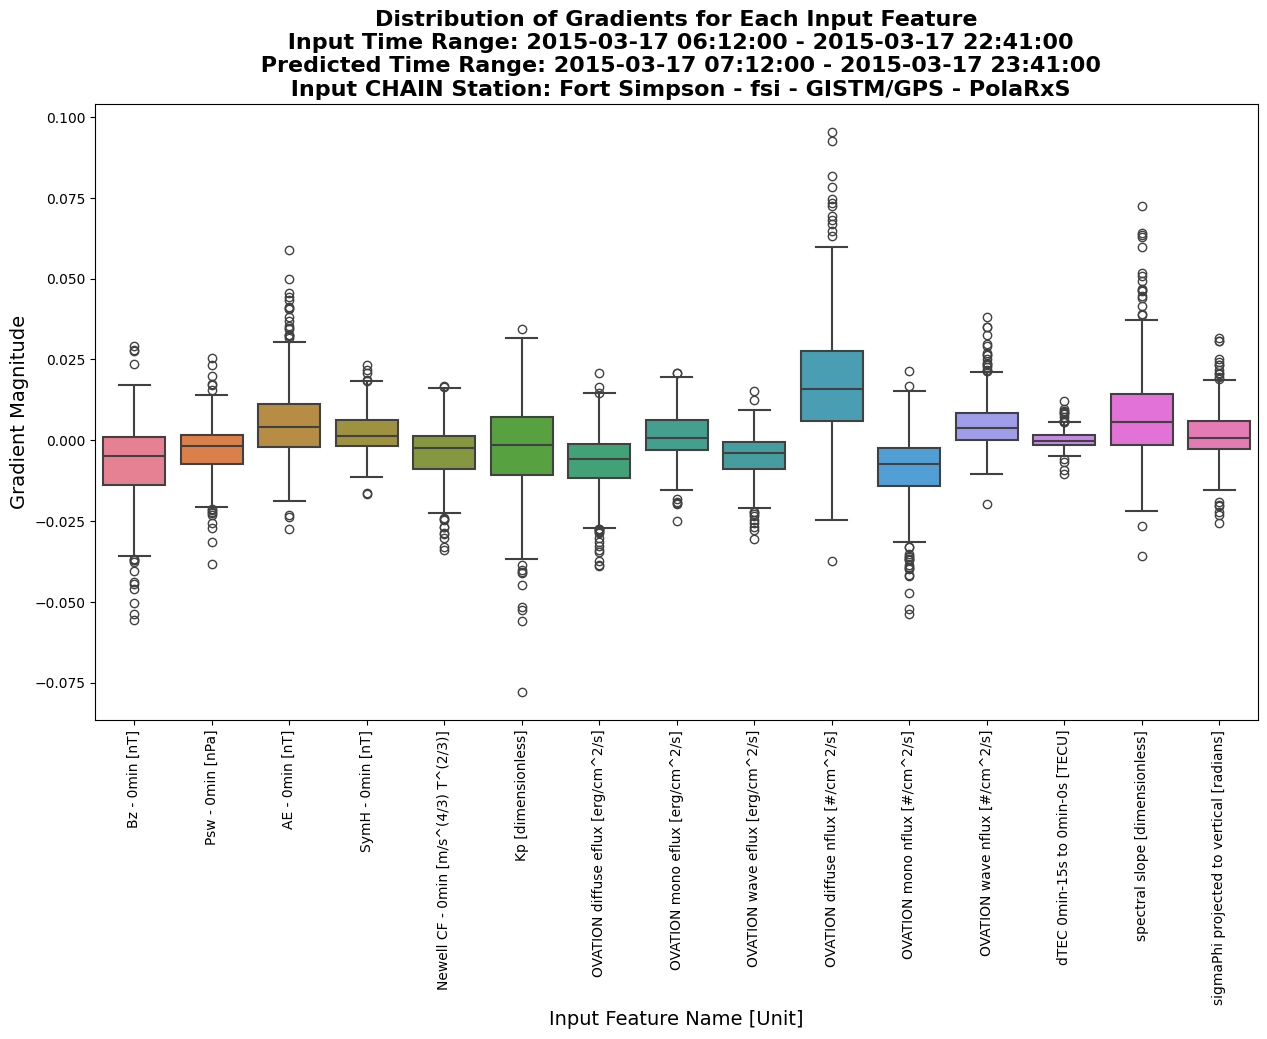

In [37]:
### violin plot / boxplot of gradient distributions per feature
all_gradients = [[] for _ in range(15)]

# for x in range(test_data.shape[0]):
for x in range(14892, 14900):
    input_sample = test_data[x].unsqueeze(0)
    input_sample = input_sample.clone().detach()
    input_sample.requires_grad_()

    output = model(input_sample)
    output_value = output[0, 0]
    output_value.backward()
    
    for feature_idx in range(test_data.shape[1]):  
        feature_gradient = input_sample.grad[0, feature_idx, :].cpu().detach().numpy()
        all_gradients[feature_idx].append(feature_gradient) 
        
flattened_gradients = [np.concatenate(grad_list) for grad_list in all_gradients]

plt.figure(figsize=(15, 8))
# sns.violinplot(data=flattened_gradients, linewidth=1.5)
sns.boxplot(data=flattened_gradients, linewidth=1.5)

plt.xlabel('Input Feature Name [Unit]', fontsize=14)
plt.ylabel('Gradient Magnitude', fontsize=14)
# plt.title('Distribution of Gradients for Each Input Feature', fontsize=18)
plt.xticks(ticks=np.arange(len(feature_names[:-1])), labels=feature_names[:-1], rotation=90)


plt.title("Distribution of Gradients for Each Input Feature" + \
             "\n Input Time Range: 2015-03-17 06:12:00 - 2015-03-17 22:41:00" + \
             "\n Predicted Time Range: 2015-03-17 07:12:00 - 2015-03-17 23:41:00" + \
             "\n Input CHAIN Station: Fort Simpson - fsi - GISTM/GPS - PolaRxS", fontsize=16, fontweight='bold', y=1)

# plt.savefig('explain_vis_boxplot_1.png', bbox_inches='tight', dpi=600)

plt.show()
